# Employee Attrition Prediction — Complete Machine Learning Analysis

## Project Objective

The objective of this project is to analyze employee data and build machine-learning classification models that can predict whether an employee is likely to leave the organization (**Attrition = Yes**) or remain (**Attrition = No**).

Although the assignment requires at least two classification algorithms, this notebook evaluates a broad range of supervised classification approaches. The purpose is to make the analysis more comprehensive and to compare models rather than relying on a single algorithm.

### Models evaluated

1. Logistic Regression
2. Ridge Logistic Regression
3. Lasso Logistic Regression
4. Elastic Net Logistic Regression
5. Decision Tree
6. Random Forest
7. K-Nearest Neighbors (KNN)
8. Support Vector Machine (SVM)
9. Gradient Boosting
10. AdaBoost
11. XGBoost

The notebook also investigates class imbalance, compares standard and imbalance-aware models, evaluates performance using several metrics, performs cross-validation, examines feature importance, and discusses possible HR/business actions.

> **Important:** Using more algorithms makes the comparison more comprehensive, but it does not automatically make the predictions "near accurate." Model quality must be judged from validation/test performance and the limitations of the available data.

## 1. Import Required Libraries

The libraries below are grouped according to their purpose:

- **Pandas / NumPy:** data handling and numerical operations
- **Matplotlib / Seaborn:** visualization
- **Scikit-learn:** preprocessing, model training, evaluation and validation
- **XGBoost:** gradient-boosted decision trees

In [1]:
import numpy as np
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The dataset contains employee information such as age, department, education, income, years at the company, overtime, job satisfaction, performance, training and the final **Attrition** outcome.

The file name used here matches the uploaded dataset. If the CSV is renamed, change the value of `file_name`.

In [2]:
file_name = "employee_attrition_dataset.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape of dataset: (800, 15)


,EmployeeID,Age,Department,EducationLevel,MonthlyIncome,YearsAtCompany,DistanceFromHome_km,OverTime,NumProjects,JobSatisfaction,WorkLifeBalance,PerformanceRating,PromotionLast5Years,TrainingHoursLastYear,Attrition
0,EMP1000,59,IT,Bachelor,68479,1,5,No,3,1,4,4,0,50,Yes
1,EMP1001,49,Finance,Master,83157,7,27,No,2,3,1,4,0,31,No
2,EMP1002,35,IT,Bachelor,64824,20,12,No,7,2,4,4,1,49,No
3,EMP1003,28,Sales,Bachelor,74028,1,17,No,2,3,1,1,0,40,No
4,EMP1004,41,HR,Bachelor,81317,3,6,No,4,1,4,2,0,65,No


## 3. Initial Data Inspection

Before building a model, we need to understand:

- how many observations and variables are present,
- what the column names are,
- the data types,
- whether values are missing,
- and the statistical characteristics of numerical variables.

This step is important because preprocessing decisions should be based on the actual dataset.

In [3]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types and Non-Null Counts:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

Column Names:
['EmployeeID', 'Age', 'Department', 'EducationLevel', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome_km', 'OverTime', 'NumProjects', 'JobSatisfaction', 'WorkLifeBalance', 'PerformanceRating', 'PromotionLast5Years', 'TrainingHoursLastYear', 'Attrition']

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   EmployeeID             800 non-null    object
 1   Age                    800 non-null    int64 
 2   Department             800 non-null    object
 3   EducationLevel         800 non-null    object
 4   MonthlyIncome          800 non-null    int64 
 5   YearsAtCompany         800 non-null    int64 
 6   DistanceFromHome_km    800 non-null    int64 
 7   OverTime               800 non-null    object
 8   NumProjects            800 non-null    int64 
 9   JobSatisfaction        

,Age,MonthlyIncome,YearsAtCompany,DistanceFromHome_km,NumProjects,JobSatisfaction,WorkLifeBalance,PerformanceRating,PromotionLast5Years,TrainingHoursLastYear
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000
mean,40.630000,67107.51375,12.375000,20.107500,3.937500,2.470000,2.495000,2.49375,0.271250,40.213750
std,11.393874,21128.62954,7.334277,11.002489,2.077014,1.130574,1.150709,1.12874,0.444883,23.259822
min,21.000000,20000.00000,0.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.000000,0.000000
25%,31.000000,52921.25000,6.000000,11.000000,2.000000,1.000000,1.000000,2.00000,0.000000,19.000000
50%,42.000000,66769.00000,13.000000,20.000000,4.000000,2.000000,3.000000,2.00000,0.000000,41.000000
75%,50.000000,81427.50000,19.000000,29.000000,6.000000,3.000000,4.000000,4.00000,1.000000,61.000000
max,59.000000,128347.00000,24.000000,39.000000,7.000000,4.000000,4.000000,4.00000,1.000000,79.000000



Missing Values:


EmployeeID               0
Age                      0
Department               0
EducationLevel           0
MonthlyIncome            0
YearsAtCompany           0
DistanceFromHome_km      0
OverTime                 0
NumProjects              0
JobSatisfaction          0
WorkLifeBalance          0
PerformanceRating        0
PromotionLast5Years      0
TrainingHoursLastYear    0
Attrition                0
dtype: int64

## 4. Standardize Column Names

The original dataset uses names such as `EmployeeID` and `WorkLifeBalance`. Converting column names to a consistent `snake_case` format makes the code easier to read and reduces typing errors.

In [4]:
df.columns = [
    re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col).lower()
    for col in df.columns
]

print("Updated column names:")
print(df.columns.tolist())

Updated column names:
['employee_id', 'age', 'department', 'education_level', 'monthly_income', 'years_at_company', 'distance_from_home_km', 'over_time', 'num_projects', 'job_satisfaction', 'work_life_balance', 'performance_rating', 'promotion_last5_years', 'training_hours_last_year', 'attrition']


## 5. Check for Missing Values

Missing values can cause errors during model training and may require imputation or removal.

Here we first identify whether missing values exist. If missing values were present, we would decide how to handle them based on the affected variable.

In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

if missing_values.sum() == 0:
    print("Result: No missing values were found.")
else:
    print("Result: Missing values were found and should be handled before modeling.")

Missing values in each column:


employee_id                 0
age                         0
department                  0
education_level             0
monthly_income              0
years_at_company            0
distance_from_home_km       0
over_time                   0
num_projects                0
job_satisfaction            0
work_life_balance           0
performance_rating          0
promotion_last5_years       0
training_hours_last_year    0
attrition                   0
dtype: int64

Result: No missing values were found.


## 6. Check for Duplicate Records

Duplicate observations can affect model evaluation because the same employee record may appear more than once.

We check duplicates before modeling. We do not automatically delete records without first identifying the situation.

In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("Result: No duplicate rows were found.")
else:
    print("Result: Duplicate rows exist. Review them before deciding whether removal is appropriate.")

Number of duplicate rows: 0
Result: No duplicate rows were found.


## 7. Outlier Analysis

Outliers are observations that are unusually far from the rest of the values.

The **Interquartile Range (IQR)** method is used:

- IQR = Q3 − Q1
- Lower limit = Q1 − 1.5 × IQR
- Upper limit = Q3 + 1.5 × IQR

This section counts potential outliers. A high outlier count does **not** automatically mean those observations should be removed. In employee data, an unusual income, age, distance or number of projects may be a genuine employee characteristic.

In [7]:
numeric_columns = df.select_dtypes(include="number").columns

outlier_summary = {}

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    outlier_summary[column] = len(outliers)

outlier_summary = (
    pd.Series(outlier_summary)
    .sort_values(ascending=False)
)

print("Potential outliers by numerical column:")
display(outlier_summary)

Potential outliers by numerical column:


monthly_income              3
age                         0
years_at_company            0
distance_from_home_km       0
num_projects                0
job_satisfaction            0
work_life_balance           0
performance_rating          0
promotion_last5_years       0
training_hours_last_year    0
dtype: int64

### Visualizing Numerical Distributions

Boxplots provide a visual way to inspect the spread and potential outliers of numerical variables.

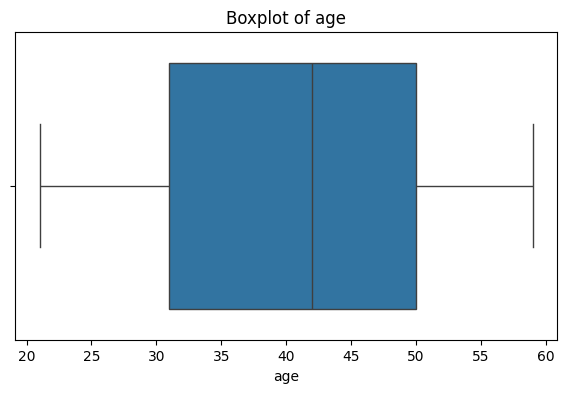

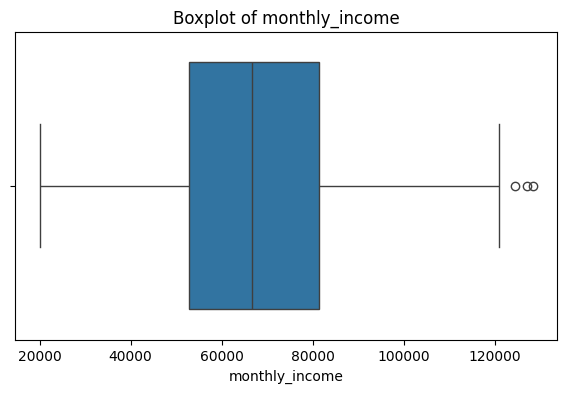

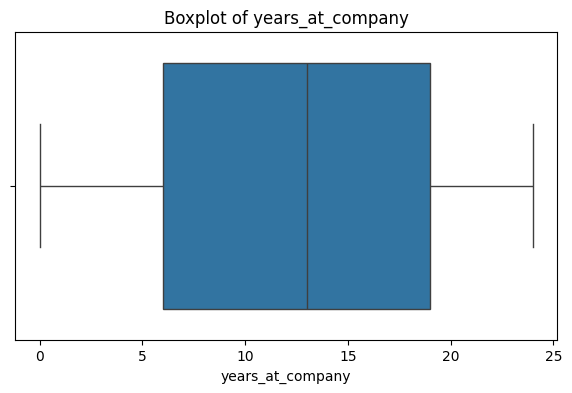

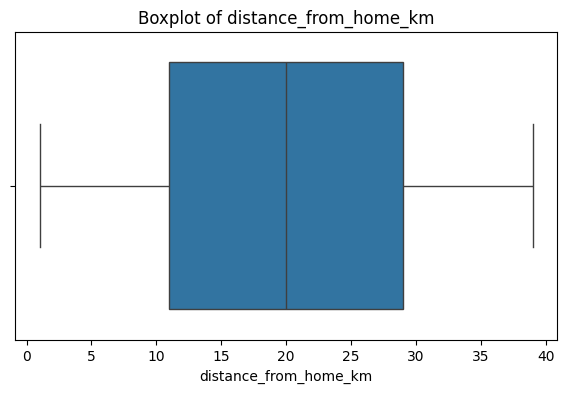

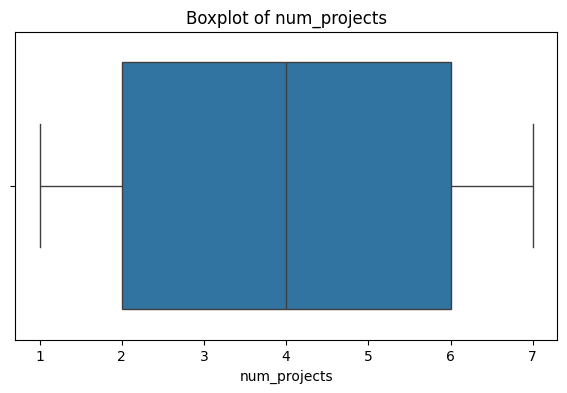

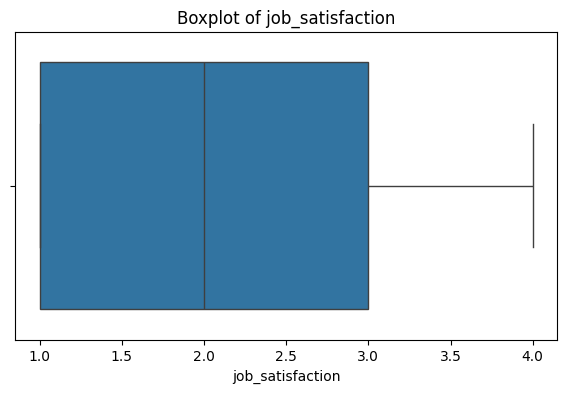

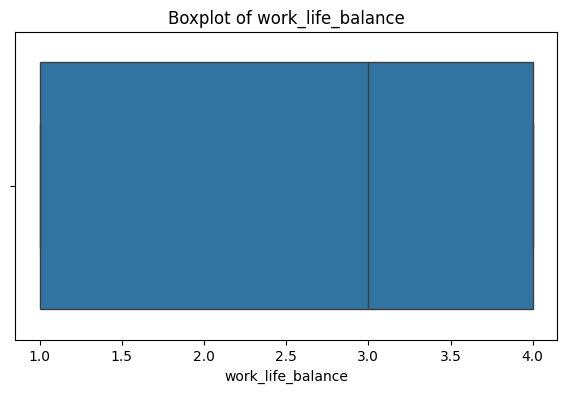

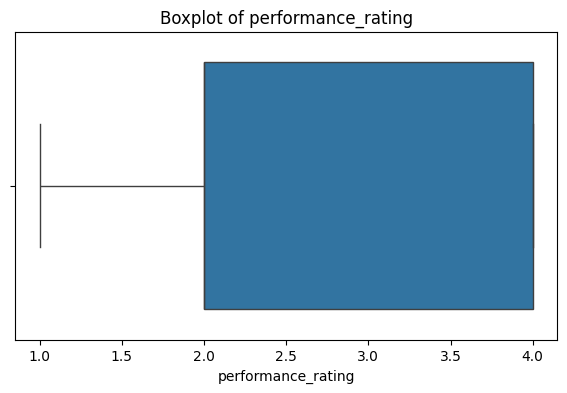

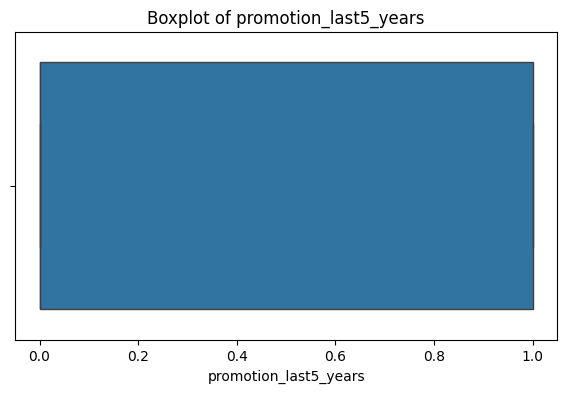

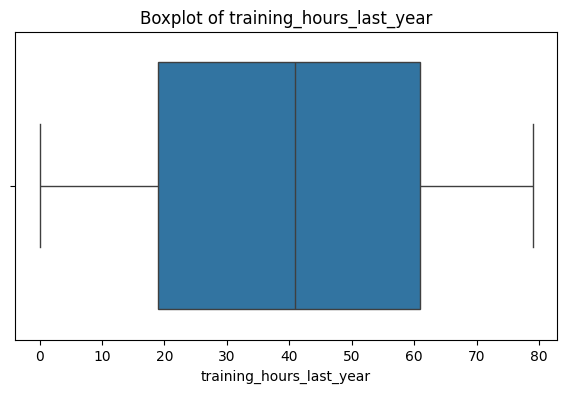

In [8]:
for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

## 8. Analyze the Target Variable — Attrition

The target variable is `Attrition`.

- **0 = No Attrition**
- **1 = Attrition**

Before training, we need to know whether both classes are represented equally. If one class is much smaller, accuracy can become misleading.

Original Attrition Values:


attrition
No     663
Yes    137
Name: count, dtype: int64


Original Attrition Percentages:


attrition
No     82.88
Yes    17.12
Name: proportion, dtype: float64

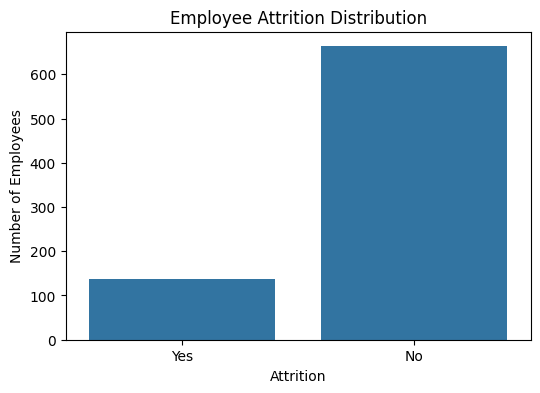

In [9]:
print("Original Attrition Values:")
display(df["attrition"].value_counts())

print("\nOriginal Attrition Percentages:")
display((df["attrition"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

### Class Imbalance Explanation

If most employees belong to the **No Attrition** class, a model can obtain high accuracy simply by predicting "No" for most employees.

For HR attrition prediction, this can be a serious issue because missing employees who are actually likely to leave can be more important than achieving a high overall accuracy.

Therefore, the analysis will report:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

We will also test imbalance-aware models.

## 9. Encode Categorical Variables

Machine-learning algorithms require numerical input.

The dataset contains:

- `OverTime` → binary encoding
- `EducationLevel` → ordered numerical encoding
- `Department` → one-hot encoding

The education levels have an apparent order from Diploma to PhD, so an ordinal mapping is used.

`Department` is nominal, so one-hot encoding is more appropriate.

In [10]:
# Encode OverTime
df["over_time"] = df["over_time"].map({
    "No": 0,
    "Yes": 1
})

# Encode EducationLevel
education_mapping = {
    "Diploma": 1,
    "Bachelor": 2,
    "Master": 3,
    "PhD": 4
}

df["education_level"] = df["education_level"].map(education_mapping)

# One-hot encode Department
df = pd.get_dummies(
    df,
    columns=["department"],
    dtype=int
)

# Encode target
df["attrition"] = df["attrition"].map({
    "No": 0,
    "Yes": 1
})

print("Encoded dataset:")
display(df.head())

Encoded dataset:


,employee_id,age,education_level,monthly_income,years_at_company,distance_from_home_km,over_time,num_projects,job_satisfaction,work_life_balance,performance_rating,promotion_last5_years,training_hours_last_year,attrition,department_Finance,department_HR,department_IT,department_R&D,department_Sales
0,EMP1000,59,2,68479,1,5,0,3,1,4,4,0,50,1,0,0,1,0,0
1,EMP1001,49,3,83157,7,27,0,2,3,1,4,0,31,0,1,0,0,0,0
2,EMP1002,35,2,64824,20,12,0,7,2,4,4,1,49,0,0,0,1,0,0
3,EMP1003,28,2,74028,1,17,0,2,3,1,1,0,40,0,0,0,0,0,1
4,EMP1004,41,2,81317,3,6,0,4,1,4,2,0,65,0,0,1,0,0,0


In [11]:
print("Data types after encoding:")
df.info()

print("\nUnique values after encoding:")
for column in ["over_time", "education_level", "attrition"]:
    print(column, sorted(df[column].dropna().unique()))

Data types after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   employee_id               800 non-null    object
 1   age                       800 non-null    int64 
 2   education_level           800 non-null    int64 
 3   monthly_income            800 non-null    int64 
 4   years_at_company          800 non-null    int64 
 5   distance_from_home_km     800 non-null    int64 
 6   over_time                 800 non-null    int64 
 7   num_projects              800 non-null    int64 
 8   job_satisfaction          800 non-null    int64 
 9   work_life_balance         800 non-null    int64 
 10  performance_rating        800 non-null    int64 
 11  promotion_last5_years     800 non-null    int64 
 12  training_hours_last_year  800 non-null    int64 
 13  attrition                 800 non-null    int64 
 14 

## 10. Check the Encoded Dataset for New Missing Values

Mapping categorical values can create missing values if an unexpected category exists. Therefore, the dataset is checked again after encoding.

In [12]:
print("Missing values after encoding:")
display(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("Result: No missing values were introduced during encoding.")
else:
    print("Result: Missing values require investigation before modeling.")

Missing values after encoding:


employee_id                 0
age                         0
education_level             0
monthly_income              0
years_at_company            0
distance_from_home_km       0
over_time                   0
num_projects                0
job_satisfaction            0
work_life_balance           0
performance_rating          0
promotion_last5_years       0
training_hours_last_year    0
attrition                   0
department_Finance          0
department_HR               0
department_IT               0
department_R&D              0
department_Sales            0
dtype: int64

Result: No missing values were introduced during encoding.


## 11. Separate Features and Target

`Attrition` is the target variable.

`EmployeeID` is removed because it is an identifier, not a meaningful predictive characteristic. Keeping an employee ID can introduce meaningless patterns into a model.

In [13]:
X = df.drop("attrition", axis=1)
X = X.drop("employee_id", axis=1)

y = df["attrition"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (800, 17)
Target shape: (800,)

Features:
['age', 'education_level', 'monthly_income', 'years_at_company', 'distance_from_home_km', 'over_time', 'num_projects', 'job_satisfaction', 'work_life_balance', 'performance_rating', 'promotion_last5_years', 'training_hours_last_year', 'department_Finance', 'department_HR', 'department_IT', 'department_R&D', 'department_Sales']


## 12. Train-Test Split — 80/20

The data is divided into:

- **80% training data** — used to train the models
- **20% testing data** — kept separate for final evaluation

`stratify=y` is used so that the proportion of Attrition/No Attrition remains approximately similar in both sets.

`random_state=42` makes the split reproducible.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts())

print("\nTesting target distribution:")
display(y_test.value_counts())

print("\nTraining target percentages:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target percentages:")
display((y_test.value_counts(normalize=True) * 100).round(2))

Training features: (640, 17)
Testing features: (160, 17)

Training target distribution:


attrition
0    530
1    110
Name: count, dtype: int64


Testing target distribution:


attrition
0    133
1     27
Name: count, dtype: int64


Training target percentages:


attrition
0    82.81
1    17.19
Name: proportion, dtype: float64


Testing target percentages:


attrition
0    83.12
1    16.88
Name: proportion, dtype: float64

## 13. Feature Scaling

Scaling places numerical features on comparable ranges.

This is particularly important for:

- Logistic Regression
- KNN
- SVM

Tree-based models do not require scaling, but using a common scaled dataset keeps the main comparison simple and consistent for this educational analysis.

**Important:** The scaler is fitted only on the training data. The test data is transformed using the already-fitted scaler. This prevents information from the test set from influencing preprocessing.

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Scaled training data:")
display(X_train_scaled.head())

Scaled training data:


,age,education_level,monthly_income,years_at_company,distance_from_home_km,over_time,num_projects,job_satisfaction,work_life_balance,performance_rating,promotion_last5_years,training_hours_last_year,department_Finance,department_HR,department_IT,department_R&D,department_Sales
539,-0.162575,-0.567510,1.584800,-0.856582,-0.273654,-0.711254,1.444715,1.399731,1.311305,-1.306054,-0.62071,-1.524550,-0.420084,-0.336219,1.799558,-0.565321,-0.608646
407,-0.162575,-0.567510,0.571245,-0.856582,1.659034,-0.711254,-1.409043,1.399731,-0.426242,-0.428956,-0.62071,-0.321347,2.380476,-0.336219,-0.555692,-0.565321,-0.608646
481,-0.775651,-1.828643,0.319061,1.486795,0.370576,-0.711254,0.969089,0.503903,-1.295015,-1.306054,-0.62071,-1.395635,-0.420084,-0.336219,-0.555692,1.768907,-0.608646
57,1.151160,-0.567510,-1.642841,0.935412,-0.917883,-0.711254,-1.409043,-0.391925,-1.295015,1.325241,-0.62071,1.311572,-0.420084,-0.336219,-0.555692,-0.565321,1.642992
136,-1.651474,0.693623,0.926410,-0.029508,1.198870,1.405967,1.444715,-0.391925,0.442531,-1.306054,-0.62071,0.409170,-0.420084,-0.336219,-0.555692,-0.565321,1.642992


## 14. Why Test Many Algorithms?

The assignment asks for at least two algorithms, but a wider comparison provides more evidence about the behavior of the dataset.

Different algorithms learn different types of patterns:

| Model | Main idea |
|---|---|
| Logistic Regression | Linear relationship between features and log-odds |
| Ridge Logistic | Logistic regression with L2 regularization |
| Lasso Logistic | Logistic regression with L1 regularization |
| Elastic Net | Combination of L1 and L2 regularization |
| Decision Tree | Rule-based recursive splits |
| Random Forest | Many decision trees combined |
| KNN | Predicts using nearby observations |
| SVM | Finds a separating decision boundary |
| Gradient Boosting | Builds trees sequentially to correct errors |
| AdaBoost | Focuses subsequent learners on difficult cases |
| XGBoost | Optimized gradient-boosted trees |

This does not mean that every model will perform equally well. The test and validation results will determine how each model behaves on this dataset.

## 15. Define the Standard Models

These models are trained without explicitly changing the class weights.

The Logistic Regression variants allow us to compare different regularization strategies.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Ridge Logistic": LogisticRegression(
        penalty="l2",
        max_iter=1000,
        random_state=42
    ),

    "Lasso Logistic": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ),

    "Elastic Net Logistic": LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    )
}

print("Number of models:", len(models))
print("\nModels:")
for name in models:
    print("-", name)

Number of models: 11

Models:
- Logistic Regression
- Ridge Logistic
- Lasso Logistic
- Elastic Net Logistic
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- SVM
- Gradient Boosting
- AdaBoost
- XGBoost


## 16. Train the Standard Models

Each model is fitted using the training data only.

In [17]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Ridge Logistic trained successfully.
Lasso Logistic trained successfully.
Elastic Net Logistic trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
K-Nearest Neighbors trained successfully.
SVM trained successfully.
Gradient Boosting trained successfully.
AdaBoost trained successfully.
XGBoost trained successfully.


## 17. Evaluate Standard Models

### Evaluation metrics

**Accuracy**  
Percentage of all predictions that are correct.

**Precision**  
Of the employees predicted as likely to leave, how many actually leave?

**Recall**  
Of the employees who actually leave, how many did the model identify?

**F1-score**  
Harmonic mean of precision and recall. It is useful when both false positives and false negatives matter.

**ROC-AUC**  
Measures how well the model separates the two classes across different probability thresholds.

Because Attrition is imbalanced, accuracy should not be considered alone.

In [18]:
standard_results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    standard_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

standard_results_df = pd.DataFrame(standard_results)

standard_results_df = standard_results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(standard_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.8500,0.6364,0.2593,0.3684,0.6636
1,Gradient Boosting,0.8562,0.7500,0.2222,0.3429,0.6736
2,Decision Tree,0.7250,0.2424,0.2963,0.2667,0.5542
3,Lasso Logistic,0.8500,1.0000,0.1111,0.2000,0.7268
4,Ridge Logistic,0.8500,1.0000,0.1111,0.2000,0.7257
5,Logistic Regression,0.8500,1.0000,0.1111,0.2000,0.7257
6,Elastic Net Logistic,0.8500,1.0000,0.1111,0.2000,0.7263
7,Random Forest,0.8500,1.0000,0.1111,0.2000,0.7314
8,K-Nearest Neighbors,0.8250,0.4286,0.1111,0.1765,0.6298
9,AdaBoost,0.8312,0.5000,0.0741,0.1290,0.6837


## 18. Classification Reports

A classification report provides precision, recall and F1-score separately for each class.

This is especially useful for checking whether the model is performing well only on the majority class.

In [19]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Attrition", "Attrition"],
        zero_division=0
    ))

Logistic Regression
              precision    recall  f1-score   support

No Attrition       0.85      1.00      0.92       133
   Attrition       1.00      0.11      0.20        27

    accuracy                           0.85       160
   macro avg       0.92      0.56      0.56       160
weighted avg       0.87      0.85      0.80       160

Ridge Logistic
              precision    recall  f1-score   support

No Attrition       0.85      1.00      0.92       133
   Attrition       1.00      0.11      0.20        27

    accuracy                           0.85       160
   macro avg       0.92      0.56      0.56       160
weighted avg       0.87      0.85      0.80       160

Lasso Logistic
              precision    recall  f1-score   support

No Attrition       0.85      1.00      0.92       133
   Attrition       1.00      0.11      0.20        27

    accuracy                           0.85       160
   macro avg       0.92      0.56      0.56       160
weighted avg       0.87 

## 19. Confusion Matrices

A confusion matrix shows:

- **True Negative (TN):** correctly predicted No Attrition
- **False Positive (FP):** predicted Attrition but employee did not leave
- **False Negative (FN):** employee left but model predicted No Attrition
- **True Positive (TP):** correctly predicted Attrition

For an HR attrition system, false negatives are important because they represent employees who may leave but were not identified by the model.

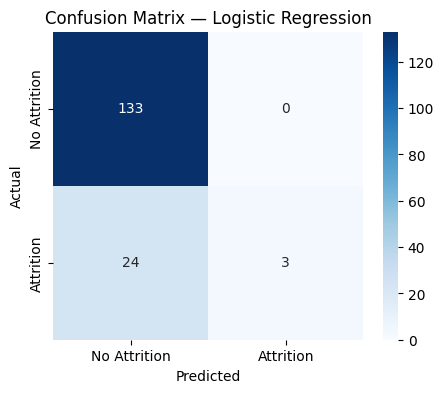

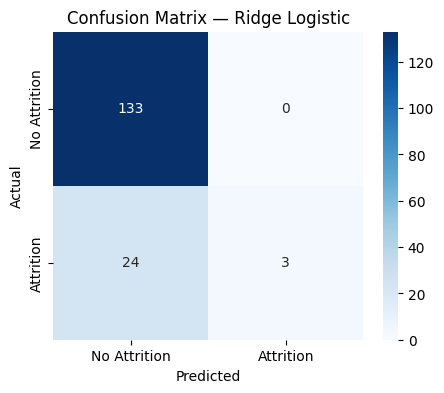

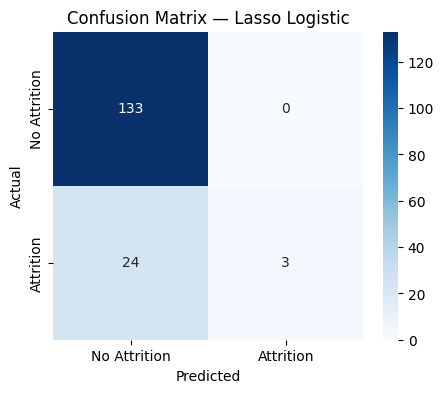

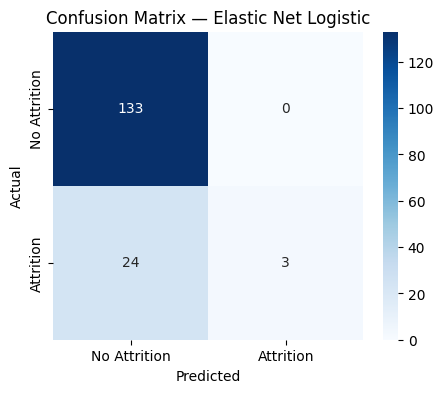

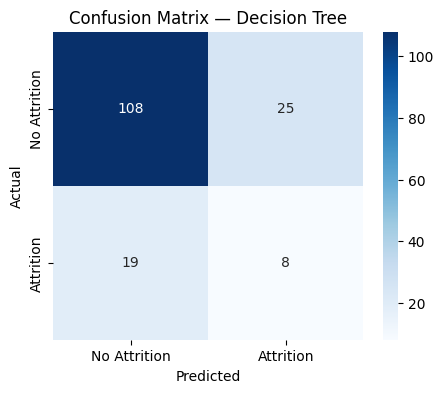

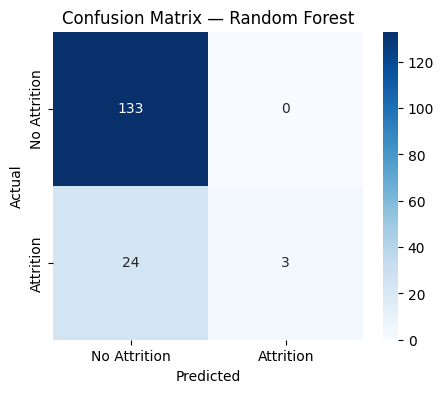

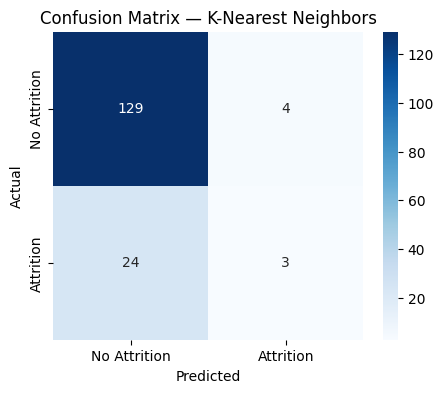

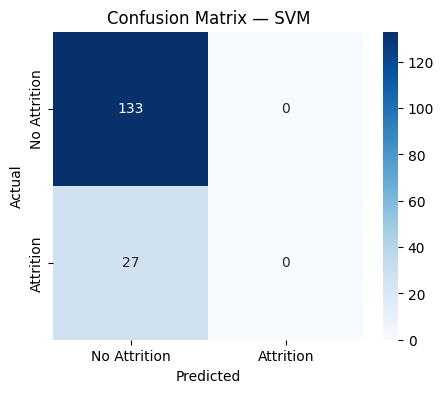

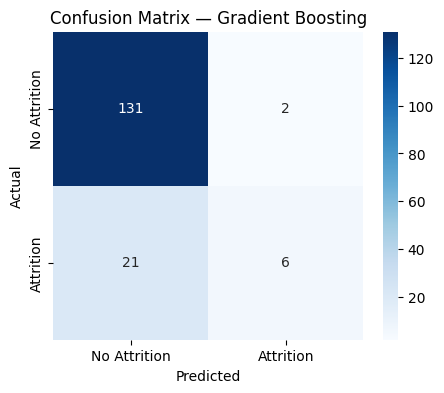

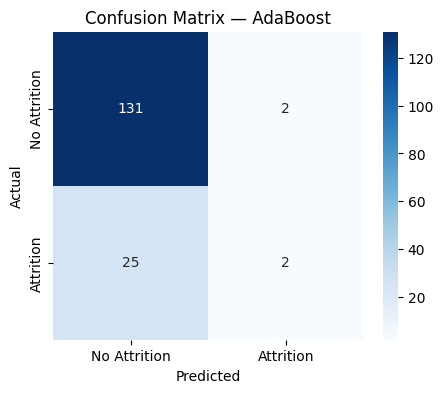

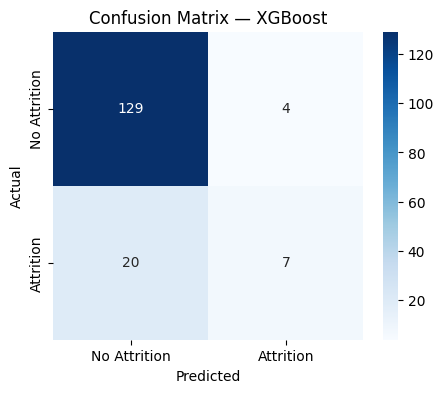

In [20]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Attrition", "Attrition"],
        yticklabels=["No Attrition", "Attrition"]
    )

    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 20. ROC Curves and AUC

The ROC curve compares the True Positive Rate against the False Positive Rate at different thresholds.

The AUC value summarizes the model's ability to distinguish the two classes.

- A value around 0.50 indicates performance close to random ranking.
- Higher values indicate better separation.

AUC should be interpreted together with recall, precision and F1-score.

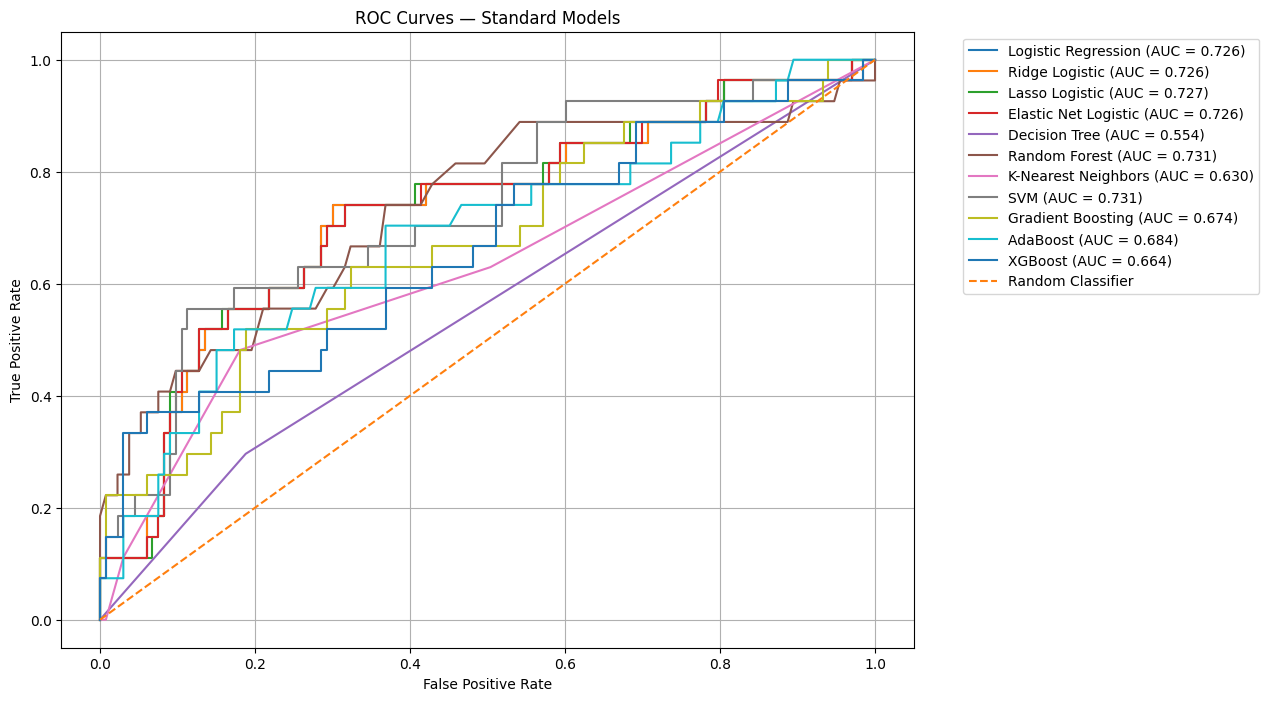

In [21]:
plt.figure(figsize=(11, 8))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Standard Models")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid()
plt.show()

## 21. Addressing Class Imbalance

The target distribution shows that Attrition is the minority class.

One approach is to give greater importance to the minority class during training using `class_weight="balanced"`.

For models that support class weights, this automatically adjusts the training cost of the classes.

KNN, Gradient Boosting and AdaBoost in this setup do not provide the same `class_weight` interface, so they are retained in the comparison without artificial changes.

This is why the next table should be described as an **imbalance-aware comparison**, not as if every algorithm had been mathematically balanced in exactly the same way.

In [22]:
imbalance_aware_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Ridge Logistic": LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Lasso Logistic": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Elastic Net Logistic": LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    )
}

imbalance_aware_trained_models = {}

for name, model in imbalance_aware_models.items():
    model.fit(X_train_scaled, y_train)
    imbalance_aware_trained_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Ridge Logistic trained successfully.
Lasso Logistic trained successfully.
Elastic Net Logistic trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
K-Nearest Neighbors trained successfully.
SVM trained successfully.
Gradient Boosting trained successfully.
AdaBoost trained successfully.
XGBoost trained successfully.


## 22. Evaluate Imbalance-Aware Models

In [23]:
imbalance_results = []

for name, model in imbalance_aware_trained_models.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    imbalance_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

imbalance_results_df = pd.DataFrame(imbalance_results)

imbalance_results_df = imbalance_results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(imbalance_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.7375,0.3469,0.6296,0.4474,0.7121
1,Ridge Logistic,0.6812,0.3065,0.7037,0.4270,0.7366
2,Logistic Regression,0.6812,0.3065,0.7037,0.4270,0.7366
3,Elastic Net Logistic,0.6688,0.2969,0.7037,0.4176,0.7374
4,Lasso Logistic,0.6625,0.2923,0.7037,0.4130,0.7377
5,XGBoost,0.8500,0.6364,0.2593,0.3684,0.6636
6,Gradient Boosting,0.8562,0.7500,0.2222,0.3429,0.6736
7,Decision Tree,0.7812,0.3462,0.3333,0.3396,0.6028
8,K-Nearest Neighbors,0.8250,0.4286,0.1111,0.1765,0.6298
9,Random Forest,0.8438,1.0000,0.0741,0.1379,0.6934


## 23. Standard vs Imbalance-Aware Comparison

The purpose of this comparison is to see how changing the treatment of the minority class affects the model.

A common pattern is:

- accuracy may decrease,
- recall for Attrition may increase,
- F1-score may improve,
- and the model may become more useful for identifying employees at risk of leaving.

There is no universal rule that the imbalance-aware model must be selected. The final choice should consider the organization's objective and the validation results.

In [24]:
standard_comparison = standard_results_df.copy()
standard_comparison["Training Approach"] = "Standard"

imbalance_comparison = imbalance_results_df.copy()
imbalance_comparison["Training Approach"] = "Imbalance-Aware"

combined_results = pd.concat(
    [standard_comparison, imbalance_comparison],
    ignore_index=True
)

combined_results = combined_results.sort_values(
    ["Model", "Training Approach"]
).reset_index(drop=True)

display(combined_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Approach
0,AdaBoost,0.8312,0.5000,0.0741,0.1290,0.6837,Imbalance-Aware
1,AdaBoost,0.8312,0.5000,0.0741,0.1290,0.6837,Standard
2,Decision Tree,0.7812,0.3462,0.3333,0.3396,0.6028,Imbalance-Aware
3,Decision Tree,0.7250,0.2424,0.2963,0.2667,0.5542,Standard
4,Elastic Net Logistic,0.6688,0.2969,0.7037,0.4176,0.7374,Imbalance-Aware
5,Elastic Net Logistic,0.8500,1.0000,0.1111,0.2000,0.7263,Standard
6,Gradient Boosting,0.8562,0.7500,0.2222,0.3429,0.6736,Imbalance-Aware
7,Gradient Boosting,0.8562,0.7500,0.2222,0.3429,0.6736,Standard
8,K-Nearest Neighbors,0.8250,0.4286,0.1111,0.1765,0.6298,Imbalance-Aware
9,K-Nearest Neighbors,0.8250,0.4286,0.1111,0.1765,0.6298,Standard


## 24. Compare F1-score and Recall Visually

Because the dataset is imbalanced, F1-score and Recall deserve special attention in addition to accuracy.

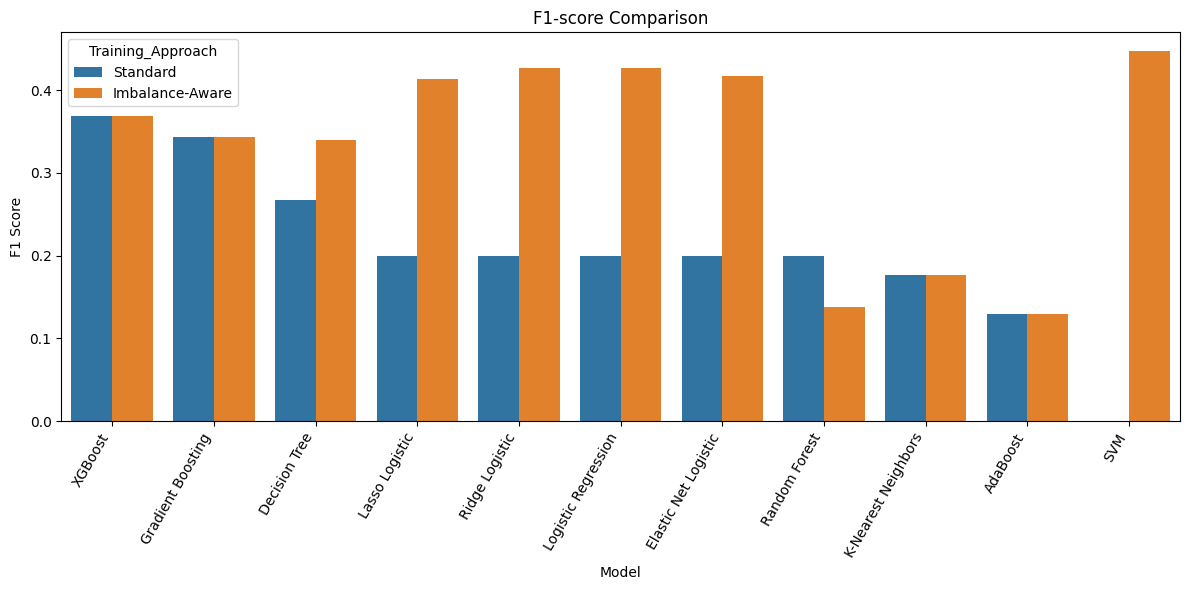

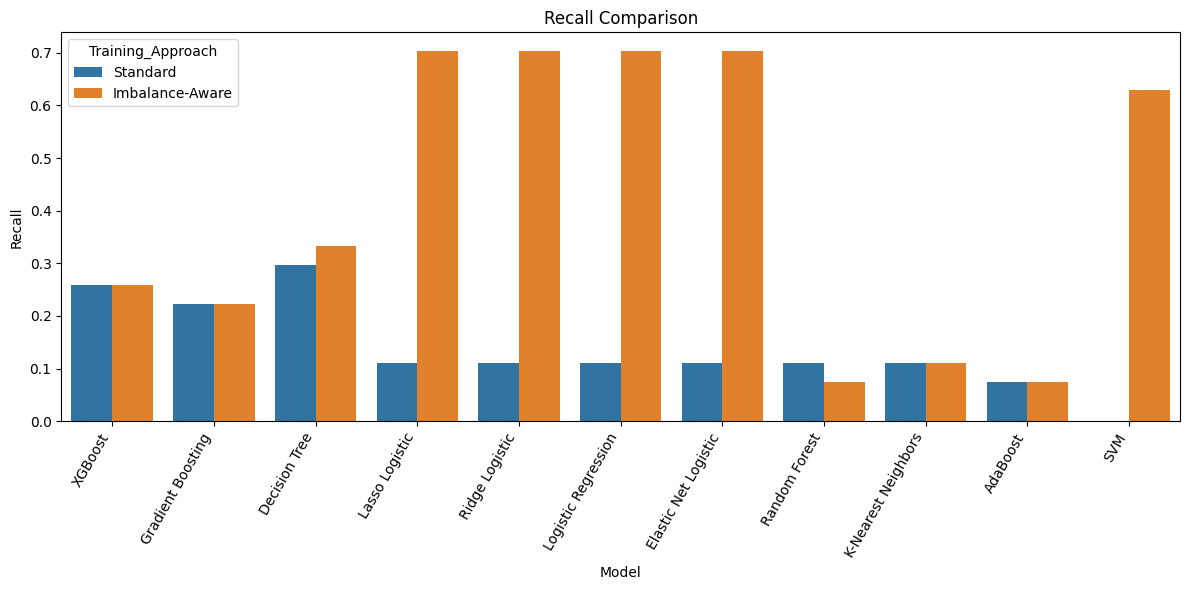

In [25]:
plot_data = pd.concat([
    standard_results_df.assign(Training_Approach="Standard"),
    imbalance_results_df.assign(Training_Approach="Imbalance-Aware")
])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_data,
    x="Model",
    y="F1 Score",
    hue="Training_Approach"
)
plt.title("F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_data,
    x="Model",
    y="Recall",
    hue="Training_Approach"
)
plt.title("Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## 25. Five-Fold Stratified Cross-Validation

A single 80/20 split can sometimes give unstable results, especially when the minority class contains relatively few observations.

To obtain a more reliable estimate, we use **5-fold Stratified Cross-Validation** on the training data.

Stratification keeps the class proportions similar across folds.

The scaler is placed inside a pipeline during cross-validation so that each fold learns scaling parameters only from its own training portion. This avoids preprocessing leakage between folds.

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in imbalance_aware_models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean CV F1",
    ascending=False
).reset_index(drop=True)

display(cv_results_df.round(4))

,Model,Mean CV F1,Std CV F1
0,Elastic Net Logistic,0.3215,0.0429
1,Ridge Logistic,0.3187,0.0420
2,Logistic Regression,0.3187,0.0420
3,Lasso Logistic,0.3177,0.0412
4,SVM,0.2905,0.0541
5,Decision Tree,0.2489,0.0467
6,XGBoost,0.2024,0.0815
7,Gradient Boosting,0.1731,0.0650
8,AdaBoost,0.1600,0.0935
9,Random Forest,0.0828,0.0877


### How to interpret cross-validation

- **Mean CV F1** shows the average F1-score across the five folds.
- **Std CV F1** shows how much the score changes from fold to fold.
- A high standard deviation means performance is less stable across different training/validation subsets.

Cross-validation is particularly useful here because the number of Attrition cases is much smaller than the number of No Attrition cases.

## 26. SMOTE — Synthetic Minority Oversampling Technique

Class imbalance was identified as an important issue in this dataset. In addition to class weighting, **SMOTE** is tested as a second imbalance-handling strategy.

SMOTE creates synthetic examples of the minority class using the training data. It is applied **only to the training folds/data**, never to the held-out test set. This prevents data leakage and gives a fair comparison between class weighting and oversampling.

The same classification algorithms are tested after SMOTE so that the effect of the imbalance-handling strategy can be compared directly.


In [27]:
# Create SMOTE versions of the same models.
# clone() gives each model a fresh, unfitted copy.
smote_models = {name: clone(model) for name, model in models.items()}

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Original training class distribution:")
print(y_train.value_counts().sort_index())

print("\nTraining class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

print("\nTraining samples before SMOTE:", len(y_train))
print("Training samples after SMOTE:", len(y_train_smote))


Original training class distribution:
attrition
0    530
1    110
Name: count, dtype: int64

Training class distribution after SMOTE:
attrition
0    530
1    530
Name: count, dtype: int64

Training samples before SMOTE: 640
Training samples after SMOTE: 1060


In [28]:
smote_trained_models = {}

for name, model in smote_models.items():
    model.fit(X_train_smote, y_train_smote)
    smote_trained_models[name] = model
    print(f"{name} trained successfully with SMOTE.")


Logistic Regression trained successfully with SMOTE.
Ridge Logistic trained successfully with SMOTE.
Lasso Logistic trained successfully with SMOTE.
Elastic Net Logistic trained successfully with SMOTE.
Decision Tree trained successfully with SMOTE.
Random Forest trained successfully with SMOTE.
K-Nearest Neighbors trained successfully with SMOTE.
SVM trained successfully with SMOTE.
Gradient Boosting trained successfully with SMOTE.
AdaBoost trained successfully with SMOTE.
XGBoost trained successfully with SMOTE.


## 27. Evaluate SMOTE Models

The SMOTE models are evaluated on the **original untouched test set**. The test data is never oversampled.


In [29]:
smote_results = []

for name, model in smote_trained_models.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    smote_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

smote_results_df = pd.DataFrame(smote_results)
smote_results_df = smote_results_df.sort_values(
    by="F1 Score", ascending=False
).reset_index(drop=True)

display(smote_results_df.round(4))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6438,0.2917,0.7778,0.4242,0.7452
1,Ridge Logistic,0.6438,0.2917,0.7778,0.4242,0.7452
2,Lasso Logistic,0.6438,0.2917,0.7778,0.4242,0.7458
3,Elastic Net Logistic,0.6438,0.2917,0.7778,0.4242,0.7455
4,SVM,0.7562,0.3421,0.4815,0.4000,0.6594
5,XGBoost,0.8438,0.5833,0.2593,0.3590,0.6185
6,K-Nearest Neighbors,0.6000,0.2394,0.6296,0.3469,0.6334
7,AdaBoost,0.7750,0.3333,0.3333,0.3333,0.6940
8,Random Forest,0.8375,0.5714,0.1481,0.2353,0.6282
9,Gradient Boosting,0.8312,0.5000,0.1481,0.2286,0.6310


## 28. Five-Fold Cross-Validation for SMOTE

To compare SMOTE fairly with class weighting, SMOTE is placed **inside the cross-validation pipeline**. Therefore, synthetic observations are generated separately inside each training fold and never from the validation fold.


In [30]:
smote_cv_results = []

for name, model in smote_models.items():

    pipeline = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    smote_cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

smote_cv_results_df = pd.DataFrame(smote_cv_results)
smote_cv_results_df = smote_cv_results_df.sort_values(
    by="Mean CV F1", ascending=False
).reset_index(drop=True)

display(smote_cv_results_df.round(4))


,Model,Mean CV F1,Std CV F1
0,Logistic Regression,0.3375,0.0259
1,Ridge Logistic,0.3375,0.0259
2,Elastic Net Logistic,0.3339,0.0311
3,Lasso Logistic,0.3295,0.0285
4,K-Nearest Neighbors,0.2789,0.0289
5,Decision Tree,0.2750,0.0508
6,AdaBoost,0.2595,0.0599
7,SVM,0.2434,0.0677
8,XGBoost,0.2230,0.1262
9,Gradient Boosting,0.1751,0.0908


## 29. Compare Class Weighting vs SMOTE

The two imbalance-handling strategies are now compared using the same evaluation criteria. This allows the final model to be selected from both approaches instead of assuming that class weighting or SMOTE is automatically better.


In [31]:
class_weight_results = imbalance_results_df.copy()
class_weight_results["Training Approach"] = "Class Weighting"

smote_results_compare = smote_results_df.copy()
smote_results_compare["Training Approach"] = "SMOTE"

imbalance_strategy_comparison = pd.concat(
    [class_weight_results, smote_results_compare],
    ignore_index=True
)

imbalance_strategy_comparison = imbalance_strategy_comparison.sort_values(
    by="F1 Score", ascending=False
).reset_index(drop=True)

print("Test-set comparison of imbalance-handling strategies:")
display(imbalance_strategy_comparison.round(4))


Test-set comparison of imbalance-handling strategies:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Approach
0,SVM,0.7375,0.3469,0.6296,0.4474,0.7121,Class Weighting
1,Ridge Logistic,0.6812,0.3065,0.7037,0.4270,0.7366,Class Weighting
2,Logistic Regression,0.6812,0.3065,0.7037,0.4270,0.7366,Class Weighting
3,Logistic Regression,0.6438,0.2917,0.7778,0.4242,0.7452,SMOTE
4,Lasso Logistic,0.6438,0.2917,0.7778,0.4242,0.7458,SMOTE
5,Ridge Logistic,0.6438,0.2917,0.7778,0.4242,0.7452,SMOTE
6,Elastic Net Logistic,0.6438,0.2917,0.7778,0.4242,0.7455,SMOTE
7,Elastic Net Logistic,0.6688,0.2969,0.7037,0.4176,0.7374,Class Weighting
8,Lasso Logistic,0.6625,0.2923,0.7037,0.4130,0.7377,Class Weighting
9,SVM,0.7562,0.3421,0.4815,0.4000,0.6594,SMOTE


## 30. Final Model Selection — Making the Decision

The analysis now moves from **model comparison** to **final model selection**.

Because Attrition is an imbalanced target, accuracy alone is not used to select the final model. A model can obtain high accuracy while failing to identify employees who actually leave.

### Predefined selection rule

The final model will be selected using:

1. **Highest Mean 5-Fold Cross-Validation F1-score** — primary criterion.
2. **Lowest CV F1 standard deviation** — first tie-breaker for stability.
3. **Highest test-set ROC-AUC** — second tie-breaker.
4. **Highest test-set Attrition Recall** — final tie-breaker.

This makes the final choice reproducible rather than manually choosing a model after seeing the results.

In [32]:
# Combine cross-validation and held-out test results for both strategies.
class_weight_cv = cv_results_df.copy()
class_weight_cv["Training Approach"] = "Class Weighting"

smote_cv = smote_cv_results_df.copy()
smote_cv["Training Approach"] = "SMOTE"

all_cv_results = pd.concat([class_weight_cv, smote_cv], ignore_index=True)

class_weight_test = imbalance_results_df.copy()
class_weight_test["Training Approach"] = "Class Weighting"

smote_test = smote_results_df.copy()
smote_test["Training Approach"] = "SMOTE"

all_test_results = pd.concat([class_weight_test, smote_test], ignore_index=True)

selection_table = all_cv_results.merge(
    all_test_results,
    on=["Model", "Training Approach"],
    how="left"
)

selection_table = selection_table.sort_values(
    by=["Mean CV F1", "Std CV F1", "ROC-AUC", "Recall"],
    ascending=[False, True, False, False]
).reset_index(drop=True)

print("Models and imbalance strategies ranked using the predefined selection rule:")
display(selection_table.round(4))

selected_model_name = selection_table.loc[0, "Model"]
selected_training_approach = selection_table.loc[0, "Training Approach"]

if selected_training_approach == "SMOTE":
    selected_model = smote_trained_models[selected_model_name]
else:
    selected_model = imbalance_aware_trained_models[selected_model_name]

print()
print("FINAL SELECTED MODEL:", selected_model_name)
print("TRAINING APPROACH:", selected_training_approach)
print("Primary selection criterion: highest Mean 5-Fold CV F1-score.")


Models and imbalance strategies ranked using the predefined selection rule:


,Model,Mean CV F1,Std CV F1,Training Approach,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.3375,0.0259,SMOTE,0.6438,0.2917,0.7778,0.4242,0.7452
1,Ridge Logistic,0.3375,0.0259,SMOTE,0.6438,0.2917,0.7778,0.4242,0.7452
2,Elastic Net Logistic,0.3339,0.0311,SMOTE,0.6438,0.2917,0.7778,0.4242,0.7455
3,Lasso Logistic,0.3295,0.0285,SMOTE,0.6438,0.2917,0.7778,0.4242,0.7458
4,Elastic Net Logistic,0.3215,0.0429,Class Weighting,0.6688,0.2969,0.7037,0.4176,0.7374
5,Ridge Logistic,0.3187,0.0420,Class Weighting,0.6812,0.3065,0.7037,0.4270,0.7366
6,Logistic Regression,0.3187,0.0420,Class Weighting,0.6812,0.3065,0.7037,0.4270,0.7366
7,Lasso Logistic,0.3177,0.0412,Class Weighting,0.6625,0.2923,0.7037,0.4130,0.7377
8,SVM,0.2905,0.0541,Class Weighting,0.7375,0.3469,0.6296,0.4474,0.7121
9,K-Nearest Neighbors,0.2789,0.0289,SMOTE,0.6000,0.2394,0.6296,0.3469,0.6334



FINAL SELECTED MODEL: Logistic Regression
TRAINING APPROACH: SMOTE
Primary selection criterion: highest Mean 5-Fold CV F1-score.


## 31. Final Selected Model — Held-Out Test Set

In [33]:
selected_y_pred = selected_model.predict(X_test_scaled)
selected_y_prob = selected_model.predict_proba(X_test_scaled)[:, 1]

selected_metrics = pd.DataFrame([{
    "Selected Model": selected_model_name,
    "Accuracy": accuracy_score(y_test, selected_y_pred),
    "Precision": precision_score(y_test, selected_y_pred, zero_division=0),
    "Recall": recall_score(y_test, selected_y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, selected_y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, selected_y_prob)
}])

display(selected_metrics.round(4))

,Selected Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6438,0.2917,0.7778,0.4242,0.7452


## 32. Final Selected Model — Classification Report

In [34]:
print("=" * 75)
print(f"FINAL SELECTED MODEL: {selected_model_name}")
print("=" * 75)

print(classification_report(
    y_test,
    selected_y_pred,
    target_names=["No Attrition", "Attrition"],
    zero_division=0
))

FINAL SELECTED MODEL: Logistic Regression
              precision    recall  f1-score   support

No Attrition       0.93      0.62      0.74       133
   Attrition       0.29      0.78      0.42        27

    accuracy                           0.64       160
   macro avg       0.61      0.70      0.58       160
weighted avg       0.82      0.64      0.69       160



## 33. Final Selected Model — Confusion Matrix

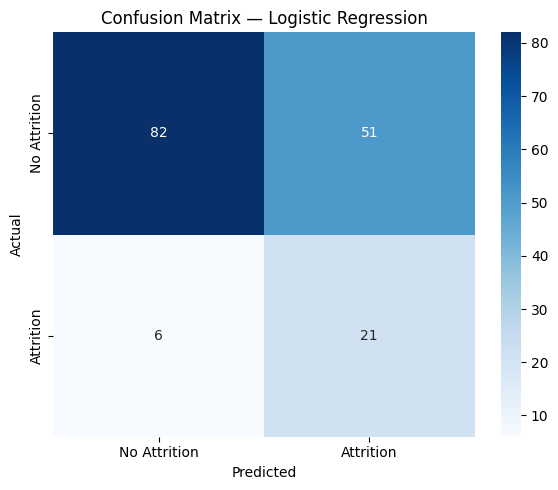

In [35]:
selected_cm = confusion_matrix(y_test, selected_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    selected_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)

plt.title(f"Confusion Matrix — {selected_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 34. Final Selected Model — ROC Curve and AUC

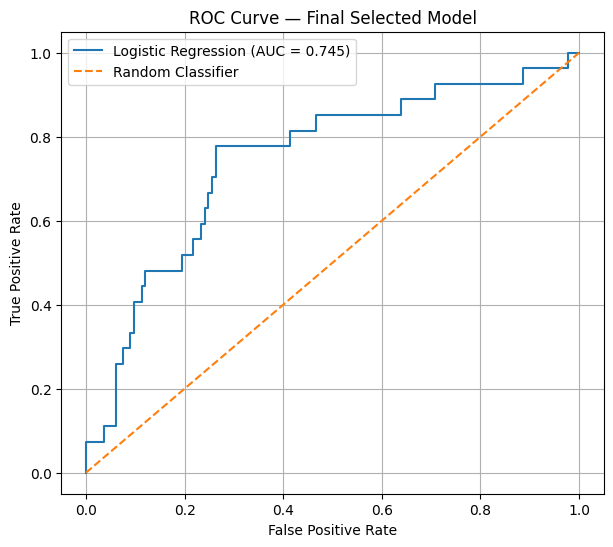

In [36]:
selected_fpr, selected_tpr, _ = roc_curve(y_test, selected_y_prob)
selected_auc = roc_auc_score(y_test, selected_y_prob)

plt.figure(figsize=(7, 6))
plt.plot(
    selected_fpr,
    selected_tpr,
    label=f"{selected_model_name} (AUC = {selected_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Selected Model")
plt.legend()
plt.grid()
plt.show()

## 35. Why This Model Was Selected

The final model was not selected simply because it had the highest accuracy.

The selection is based primarily on **mean F1-score across five stratified cross-validation folds**. This is appropriate because the Attrition class is imbalanced and F1 balances Precision and Recall.

The held-out test set was not used to select the model. It is used here for the final performance report.

In [37]:
best_cv_row = selection_table.iloc[0]

print("=" * 75)
print("FINAL MODEL DECISION")
print("=" * 75)
print(f"Selected model: {selected_model_name}")
print(f"Mean CV F1: {best_cv_row['Mean CV F1']:.4f}")
print(f"CV F1 standard deviation: {best_cv_row['Std CV F1']:.4f}")
print(f"Test Accuracy: {best_cv_row['Accuracy']:.4f}")
print(f"Test Precision: {best_cv_row['Precision']:.4f}")
print(f"Test Recall: {best_cv_row['Recall']:.4f}")
print(f"Test F1: {best_cv_row['F1 Score']:.4f}")
print(f"Test ROC-AUC: {best_cv_row['ROC-AUC']:.4f}")
print("=" * 75)

FINAL MODEL DECISION
Selected model: Logistic Regression
Mean CV F1: 0.3375
CV F1 standard deviation: 0.0259
Test Accuracy: 0.6438
Test Precision: 0.2917
Test Recall: 0.7778
Test F1: 0.4242
Test ROC-AUC: 0.7452


## 36. Feature Importance / Interpretation of the Selected Model

Where the selected algorithm provides native feature importance or coefficients, they are displayed below.

- Tree models → feature importance
- Logistic models → coefficients
- Other algorithms → Random Forest importance is retained as a supporting dataset-level interpretation.

These measures describe predictive contribution or association, not causation.

,Feature,Coefficient,Absolute Coefficient
0,monthly_income,-0.4335,0.4335
1,over_time,0.3548,0.3548
2,years_at_company,-0.2813,0.2813
3,distance_from_home_km,0.2391,0.2391
4,department_Finance,-0.1738,0.1738
5,training_hours_last_year,-0.1723,0.1723
6,promotion_last5_years,-0.1718,0.1718
7,work_life_balance,0.1476,0.1476
8,department_IT,0.1393,0.1393
9,age,0.0813,0.0813


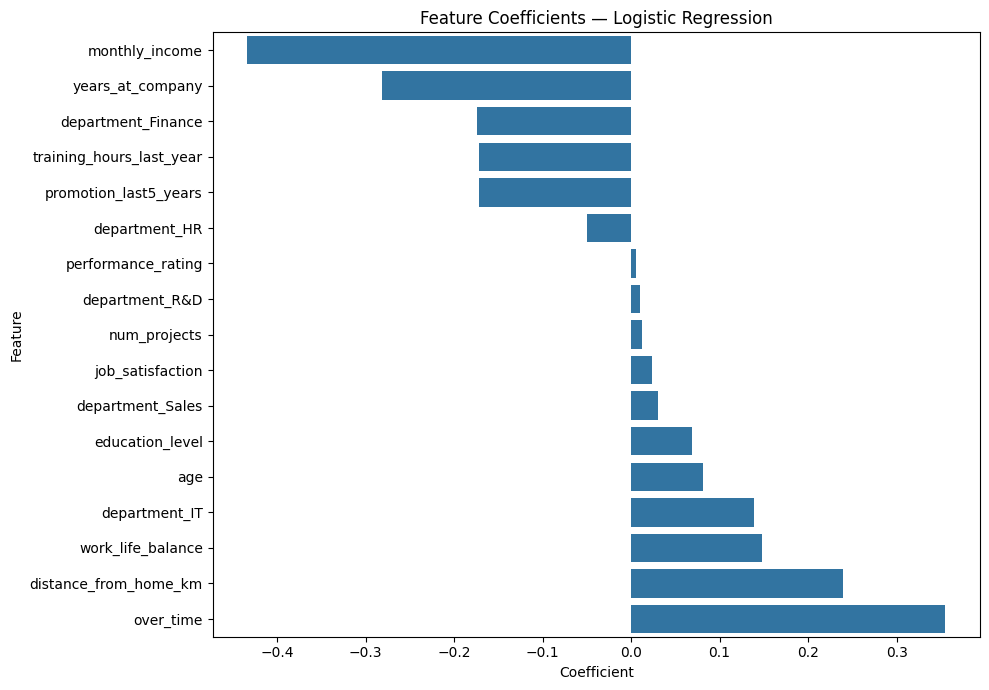

In [38]:
if hasattr(selected_model, "feature_importances_"):

    selected_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": selected_model.feature_importances_
    }).sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    display(selected_importance.round(4))

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=selected_importance,
        x="Importance",
        y="Feature"
    )
    plt.title(f"Feature Importance — {selected_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

elif hasattr(selected_model, "coef_"):

    selected_coefficients = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": selected_model.coef_[0]
    })

    selected_coefficients["Absolute Coefficient"] = (
        selected_coefficients["Coefficient"].abs()
    )

    selected_coefficients = selected_coefficients.sort_values(
        by="Absolute Coefficient",
        ascending=False
    ).reset_index(drop=True)

    display(selected_coefficients.round(4))

    plt.figure(figsize=(10, 7))
    coefficient_plot = selected_coefficients.sort_values("Coefficient")

    sns.barplot(
        data=coefficient_plot,
        x="Coefficient",
        y="Feature"
    )
    plt.title(f"Feature Coefficients — {selected_model_name}")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    print(
        f"{selected_model_name} does not provide direct feature importance "
        "or coefficients."
    )
    print(
        "Use the Random Forest feature-importance analysis above as a "
        "supporting interpretation."
    )

## 37. HR / Business Interpretation

The model should be treated as a **decision-support tool**, not an automatic employee decision-maker.

If variables such as overtime, income, tenure, satisfaction, work-life balance or promotion history are important, HR can investigate the underlying organizational patterns.

Possible areas for investigation include workload, compensation, retention by tenure, employee experience and career-development opportunities.

Model importance does not prove that changing a variable will cause an employee to stay or leave.

In [39]:
# Display the top Random Forest predictive features.
# This cell creates the table itself, so it does not depend
# on a variable created in an earlier section.

rf_model = imbalance_aware_trained_models["Random Forest"]

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)

print("Top 10 predictive features from the Random Forest analysis:")
display(rf_importance.head(10).round(4))


Top 10 predictive features from the Random Forest analysis:


,Feature,Importance
0,monthly_income,0.1640
1,training_hours_last_year,0.1329
2,years_at_company,0.1198
3,age,0.1146
4,distance_from_home_km,0.1030
5,num_projects,0.0622
6,work_life_balance,0.0477
7,job_satisfaction,0.0469
8,performance_rating,0.0443
9,education_level,0.0363


## 38. Final Limitations

1. The dataset contains only 800 employee records.
2. Attrition is the minority class, so metrics can be sensitive to the relatively small number of positive cases.
3. Important HR variables may be absent, such as engagement, manager relationship, organizational culture and career opportunities.
4. Historical patterns may change over time.
5. Feature importance and coefficients show model relationships, not causation.
6. The test set is one held-out sample; cross-validation improves the assessment but does not eliminate uncertainty.
7. The default probability threshold of 0.50 may not be optimal for every HR use case.
8. Prediction quality depends on the quality and completeness of the original HR data.

## 39. Future Improvements

Possible improvements include:

- collecting more employee records;
- adding richer HR and engagement variables;
- testing alternative imbalance strategies such as SMOTE on additional datasets;
- hyperparameter tuning with cross-validation;
- optimizing the classification threshold according to HR costs;
- probability calibration;
- testing additional ensemble models;
- using a complete preprocessing/model pipeline;
- monitoring performance after deployment;
- checking appropriate fairness and subgroup performance;
- periodically retraining the model as workforce behavior changes.

## 40. Final Conclusion

This project goes substantially beyond the minimum requirement of two algorithms.

Eleven classification approaches were evaluated across several model families. The analysis included data-quality checks, outlier analysis, class-imbalance analysis, encoding, scaling, stratified train-test splitting, multiple evaluation metrics, confusion matrices, ROC-AUC, class weighting, SMOTE, cross-validation and feature interpretation.

Most importantly, the notebook now reaches an **actual final model decision**.

Both class weighting and SMOTE were evaluated. The final model and imbalance-handling strategy are selected automatically using the predefined F1-based cross-validation rule, and the final test-set performance is reported above.

The result should be described as an **employee attrition risk prediction model**, not as a perfect predictor of individual employee behavior.

In [40]:
print("=" * 80)
print("FINAL PROJECT RESULT")
print("=" * 80)
print(f"Selected model: {selected_model_name}")
print(f"Training approach: {selected_training_approach}")
print(f"Mean 5-Fold CV F1: {best_cv_row['Mean CV F1']:.4f}")
print(f"Test Accuracy: {best_cv_row['Accuracy']:.4f}")
print(f"Test Precision: {best_cv_row['Precision']:.4f}")
print(f"Test Recall: {best_cv_row['Recall']:.4f}")
print(f"Test F1: {best_cv_row['F1 Score']:.4f}")
print(f"Test ROC-AUC: {best_cv_row['ROC-AUC']:.4f}")
print("=" * 80)


FINAL PROJECT RESULT
Selected model: Logistic Regression
Training approach: SMOTE
Mean 5-Fold CV F1: 0.3375
Test Accuracy: 0.6438
Test Precision: 0.2917
Test Recall: 0.7778
Test F1: 0.4242
Test ROC-AUC: 0.7452


# 41. Recommended Committee Presentation Sequence

1. Problem statement — predict employee attrition.
2. Dataset and variables.
3. Data inspection and statistics.
4. Missing values, duplicates and outliers.
5. Attrition class imbalance.
6. Encoding and preprocessing.
7. 80/20 stratified split.
8. Why multiple algorithms were evaluated.
9. Standard model comparison.
10. Imbalance-aware model comparison.
11. Five-fold stratified cross-validation.
12. **Final selected model.**
13. Final performance metrics.
14. Confusion matrix.
15. ROC-AUC.
16. Feature importance.
17. HR/business interpretation.
18. Limitations and future improvements.
19. Final conclusion.

### Suggested explanation to the committee

> Although the assignment required at least two algorithms, I evaluated eleven classification approaches because different algorithms can learn different patterns from the same data. I did not select the final model using accuracy alone. Because attrition is imbalanced, I compared Precision, Recall, F1-score and ROC-AUC, evaluated imbalance-aware models, and used five-fold stratified cross-validation to make the final model selection reproducible.